# Surface Code Memory Experiments: Selene + MWPM Decoding

This notebook demonstrates surface code memory experiments at distances 3, 5, 7, and 9
using Selene for noisy simulation with circuit-level depolarizing noise, decoded with
MWPM decoders:

- **PyMatching**: MWPM decoder (C++)
- **FusionBlossom**: MWPM decoder (Rust)

Both decoders use PECOS native circuit-level DEMs. Each experiment uses 2*d syndrome
extraction rounds.

**Outline:**
1. Surface code visualization
2. Noiseless verification
3. Decoded experiments (Z and X basis, both decoders)
4. Logical error rate per syndrome round
5. Shot count estimation for experiments

In [1]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from pecos.compilation_pipeline import compile_guppy_to_hugr
from pecos.guppy.surface import get_num_qubits, make_surface_code
from pecos.qec.surface import NoiseModel, SurfaceDecoder, SurfacePatch, plot_surface_code
from selene_sim import DepolarizingErrorModel, IdealErrorModel, SimpleRuntime, Stim, build

## Configuration

In [2]:
DISTANCES = [3, 5, 7, 9]
NUM_SHOTS = 1000
DECODER_TYPES = ["pymatching", "fusion_blossom"]

# Uniform depolarizing noise: p1 = p2 = p_meas = p_init = p
ERROR_RATES = [0.001, 0.002, 0.005, 0.008, 0.01]

## Surface Code Visualization

/tmp/ipykernel_468592/1128976169.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_d.show()


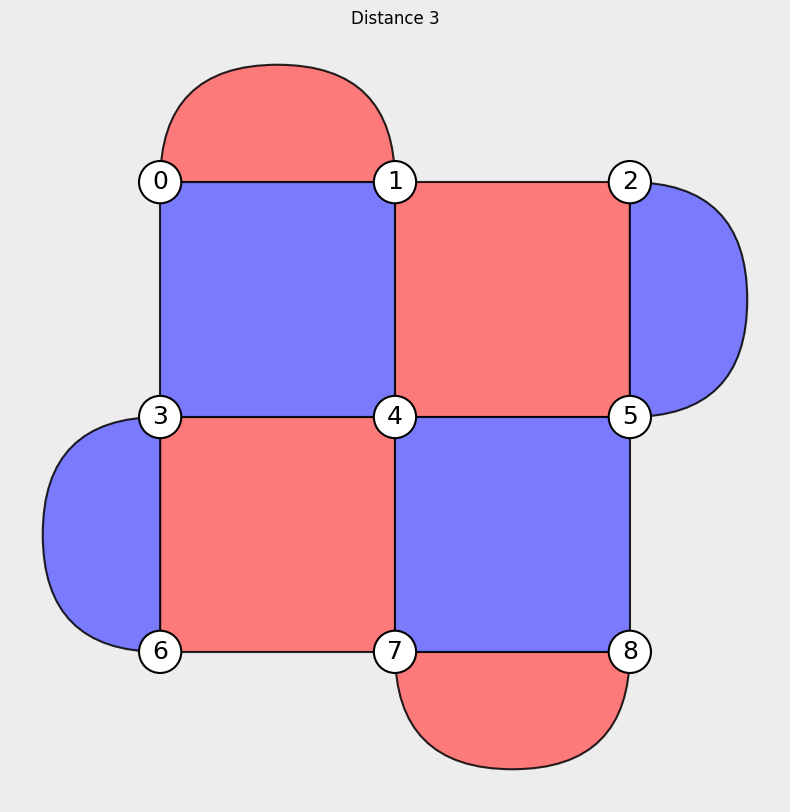

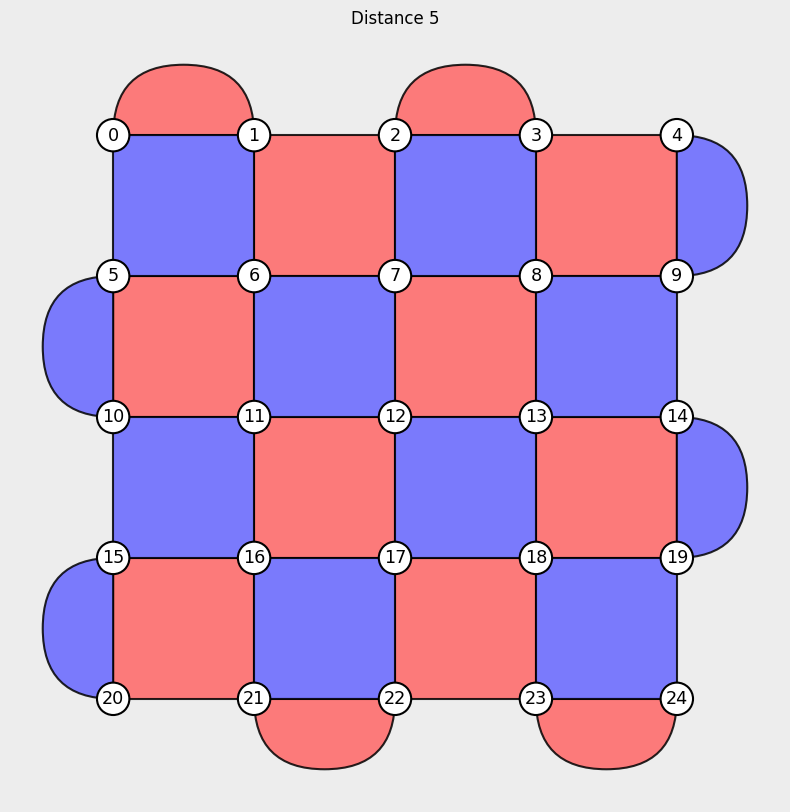

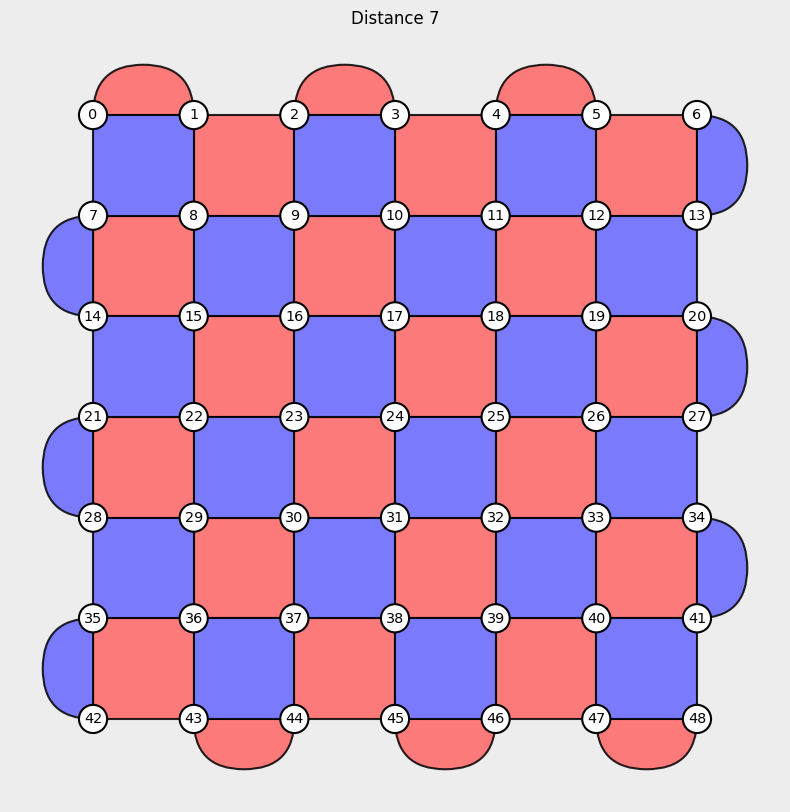

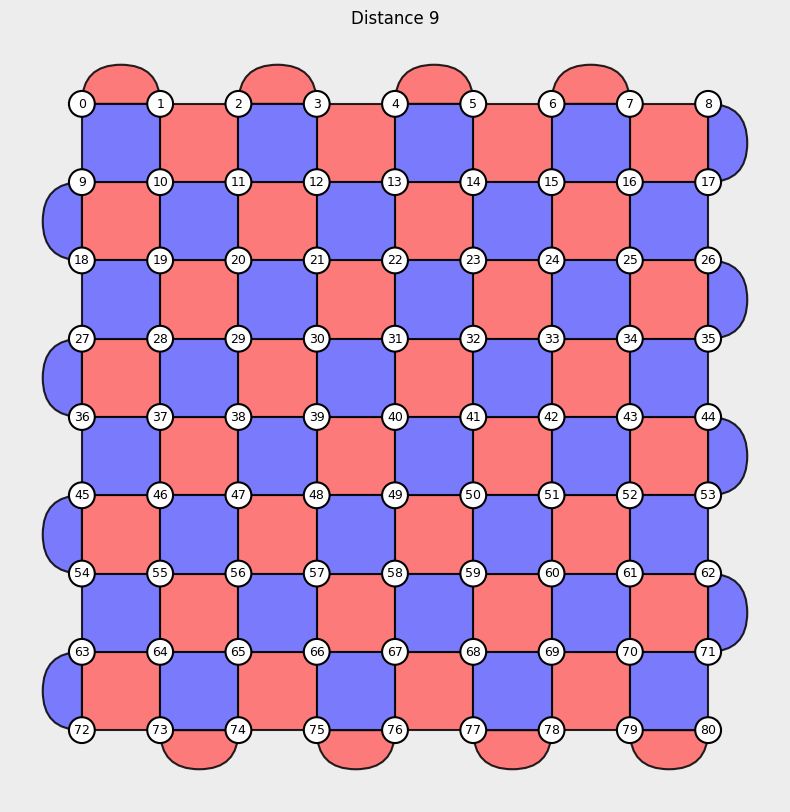

In [3]:
for d in DISTANCES:
    fig_d, ax_d = plot_surface_code(d, show_cnot_order=False)
    ax_d.set_title(f"Distance {d}", fontsize=12)
    fig_d.show()

## Helper Functions

Circuits are compiled once per (distance, num_rounds, basis) and reused across error rates.

In [4]:
def compile_circuit(distance: int, num_rounds: int, basis: str):
    """Compile a surface code circuit once, return (instance, num_qubits)."""
    num_qubits = get_num_qubits(distance)
    prog = make_surface_code(distance=distance, num_rounds=num_rounds, basis=basis)
    hugr_bytes = compile_guppy_to_hugr(prog)
    instance = build(hugr_bytes, name=f"surface_d{distance}_{basis}_{num_rounds}r")
    return instance, num_qubits


def run_shots(instance, num_qubits: int, num_shots: int, error_model: Any):
    """Run shots and collect syndrome/final data."""
    all_shots = []
    for shot_results in instance.run_shots(
        simulator=Stim(),
        n_qubits=num_qubits,
        n_shots=num_shots,
        error_model=error_model,
        runtime=SimpleRuntime(),
        n_processes=1,
    ):
        synx_list = []
        synz_list = []
        final = None
        for name, values in shot_results:
            vals = list(values)
            if name == "synx":
                synx_list.append(np.array(vals, dtype=np.uint8))
            elif name == "synz":
                synz_list.append(np.array(vals, dtype=np.uint8))
            elif name == "final":
                final = np.array(vals, dtype=np.uint8)
        if final is not None:
            all_shots.append((synx_list, synz_list, final))
    return all_shots


def decode_shots(
    shots: list,
    decoder: SurfaceDecoder,
    basis: str,
    logical_qubits: tuple,
) -> dict:
    """Decode collected shots and compute error rates."""
    num_logical_errors = 0
    num_raw_errors = 0

    for synx_list, synz_list, final in shots:
        raw_parity = sum(int(final[q]) for q in logical_qubits) % 2
        if raw_parity != 0:
            num_raw_errors += 1

        if basis == "Z":
            is_error, _ = decoder.decode_memory_z(synx_list, synz_list, final)
        else:
            is_error, _ = decoder.decode_memory_x(synx_list, synz_list, final)
        if is_error:
            num_logical_errors += 1

    n = len(shots)
    return {
        "num_shots": n,
        "num_logical_errors": num_logical_errors,
        "num_raw_errors": num_raw_errors,
        "logical_error_rate": num_logical_errors / n if n > 0 else 0,
        "raw_error_rate": num_raw_errors / n if n > 0 else 0,
    }

## Part 1: Noiseless Verification

Verify the circuit works correctly with no noise for all distances and both bases.

In [5]:
print("=== Noiseless Verification ===")
print()

for basis in ["Z", "X"]:
    for d in DISTANCES:
        num_rounds = 2 * d
        instance, nq = compile_circuit(d, num_rounds, basis)
        shots = run_shots(instance, nq, 100, IdealErrorModel())
        logical_qubits = SurfacePatch.create(d).geometry.logical_z.data_qubits if basis == "Z" \
            else SurfacePatch.create(d).geometry.logical_x.data_qubits
        raw_errors = sum(1 for _, _, final in shots if sum(int(final[q]) for q in logical_qubits) % 2 != 0)
        status = "OK" if raw_errors == 0 else "FAIL"
        print(f"  d={d}, {basis}-basis, {num_rounds} rounds: {raw_errors}/100 errors [{status}]")
    print()

=== Noiseless Verification ===



  d=3, Z-basis, 6 rounds: 0/100 errors [OK]


  d=5, Z-basis, 10 rounds: 0/100 errors [OK]


  d=7, Z-basis, 14 rounds: 0/100 errors [OK]


  d=9, Z-basis, 18 rounds: 0/100 errors [OK]



  d=3, X-basis, 6 rounds: 0/100 errors [OK]


  d=5, X-basis, 10 rounds: 0/100 errors [OK]


  d=7, X-basis, 14 rounds: 0/100 errors [OK]


  d=9, X-basis, 18 rounds: 0/100 errors [OK]



## Part 2: Decoded Experiments (Z Basis)

Run Z-basis memory experiments with `2*d` syndrome rounds for each distance.
Compare PyMatching and FusionBlossom MWPM decoders.

Circuits are compiled once per distance; shots are simulated once per (distance, error rate)
and reused across both decoders.

In [6]:
# results_z[decoder_type] = [(d, p, decoded_ler, raw_ler), ...]
results_z = {dt: [] for dt in DECODER_TYPES}

print("=== Z Basis Experiments (2*d rounds) ===")

for d in DISTANCES:
    num_rounds = 2 * d
    instance, nq = compile_circuit(d, num_rounds, "Z")
    patch = SurfacePatch.create(d)
    logical_qubits = patch.geometry.logical_z.data_qubits

    for p in ERROR_RATES:
        error_model = DepolarizingErrorModel(p_1q=p, p_2q=p, p_meas=p, p_init=p)
        noise = NoiseModel(p1=p, p2=p, p_meas=p, p_init=p)

        # Simulate once, decode with all decoders
        shots = run_shots(instance, nq, NUM_SHOTS, error_model)

        line_parts = [f"d={d} p={p:.3f}:"]
        for dt in DECODER_TYPES:
            decoder = SurfaceDecoder(patch, num_rounds=num_rounds, noise=noise, decoder_type=dt)
            res = decode_shots(shots, decoder, "Z", logical_qubits)
            results_z[dt].append((d, p, res["logical_error_rate"], res["raw_error_rate"]))
            line_parts.append(f"{dt}={res['logical_error_rate']:.4f}")

        print("  ".join(line_parts))
    print()

=== Z Basis Experiments (2*d rounds) ===


d=3 p=0.001:  pymatching=0.0150  fusion_blossom=0.0490
d=3 p=0.002:  pymatching=0.0330  fusion_blossom=0.1150


d=3 p=0.005:  pymatching=0.1720  fusion_blossom=0.2840


d=3 p=0.008:  pymatching=0.3010  fusion_blossom=0.3670


d=3 p=0.010:  pymatching=0.3330  fusion_blossom=0.4180



...

d=9 p=0.001:  pymatching=0.0030  fusion_blossom=0.2170


d=9 p=0.002:  pymatching=0.0410  fusion_blossom=0.3910


d=9 p=0.005:  pymatching=0.4540  fusion_blossom=0.4840


d=9 p=0.008:  pymatching=0.5110  fusion_blossom=0.5200


d=9 p=0.010:  pymatching=0.5320  fusion_blossom=0.5010



## Part 3: Decoded Experiments (X Basis)

In [7]:
results_x = {dt: [] for dt in DECODER_TYPES}

print("=== X Basis Experiments (2*d rounds) ===")

for d in DISTANCES:
    num_rounds = 2 * d
    instance, nq = compile_circuit(d, num_rounds, "X")
    patch = SurfacePatch.create(d)
    logical_qubits = patch.geometry.logical_x.data_qubits

    for p in ERROR_RATES:
        error_model = DepolarizingErrorModel(p_1q=p, p_2q=p, p_meas=p, p_init=p)
        noise = NoiseModel(p1=p, p2=p, p_meas=p, p_init=p)

        shots = run_shots(instance, nq, NUM_SHOTS, error_model)

        line_parts = [f"d={d} p={p:.3f}:"]
        for dt in DECODER_TYPES:
            decoder = SurfaceDecoder(patch, num_rounds=num_rounds, noise=noise, decoder_type=dt)
            res = decode_shots(shots, decoder, "X", logical_qubits)
            results_x[dt].append((d, p, res["logical_error_rate"], res["raw_error_rate"]))
            line_parts.append(f"{dt}={res['logical_error_rate']:.4f}")

        print("  ".join(line_parts))
    print()

=== X Basis Experiments (2*d rounds) ===


d=3 p=0.001:  pymatching=0.0200  fusion_blossom=0.0600


d=3 p=0.002:  pymatching=0.0520  fusion_blossom=0.1130


d=3 p=0.005:  pymatching=0.1990  fusion_blossom=0.2960


d=3 p=0.008:  pymatching=0.3310  fusion_blossom=0.4190


...

d=9 p=0.001:  pymatching=0.0040  fusion_blossom=0.2470


d=9 p=0.002:  pymatching=0.0630  fusion_blossom=0.3860


d=9 p=0.005:  pymatching=0.4970  fusion_blossom=0.4940


d=9 p=0.008:  pymatching=0.5140  fusion_blossom=0.4780


d=9 p=0.010:  pymatching=0.4860  fusion_blossom=0.4840



## Part 4: Results Visualization

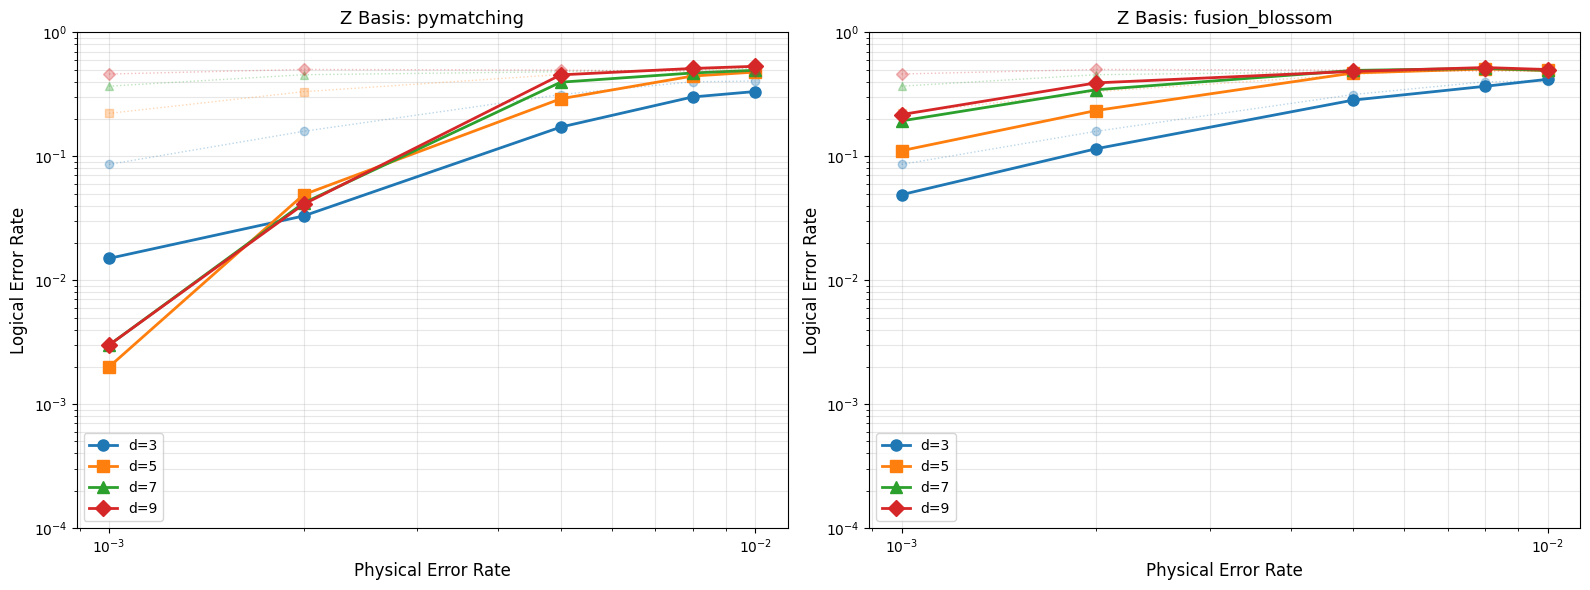

In [8]:
# Z basis: compare decoders
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
markers = ["o", "s", "^", "D"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, dt in zip(axes, DECODER_TYPES, strict=False):
    for i, d in enumerate(DISTANCES):
        d_dec = [(p, dec) for (dd, p, dec, raw) in results_z[dt] if dd == d]
        if d_dec:
            ps, lers = zip(*d_dec, strict=False)
            lers_plot = [max(v, 1e-4) for v in lers]
            ax.plot(ps, lers_plot, f"{markers[i]}-", color=colors[i],
                    label=f"d={d}", markersize=8, linewidth=2)

        d_raw = [(p, raw) for (dd, p, dec, raw) in results_z[dt] if dd == d]
        if d_raw:
            ps, lers = zip(*d_raw, strict=False)
            lers_plot = [max(v, 1e-4) for v in lers]
            ax.plot(ps, lers_plot, f"{markers[i]}:", color=colors[i],
                    alpha=0.3, markersize=6, linewidth=1)

    ax.set_xlabel("Physical Error Rate", fontsize=12)
    ax.set_ylabel("Logical Error Rate", fontsize=12)
    ax.set_title(f"Z Basis: {dt}", fontsize=13)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_ylim(1e-4, 1.0)

plt.tight_layout()
plt.show()

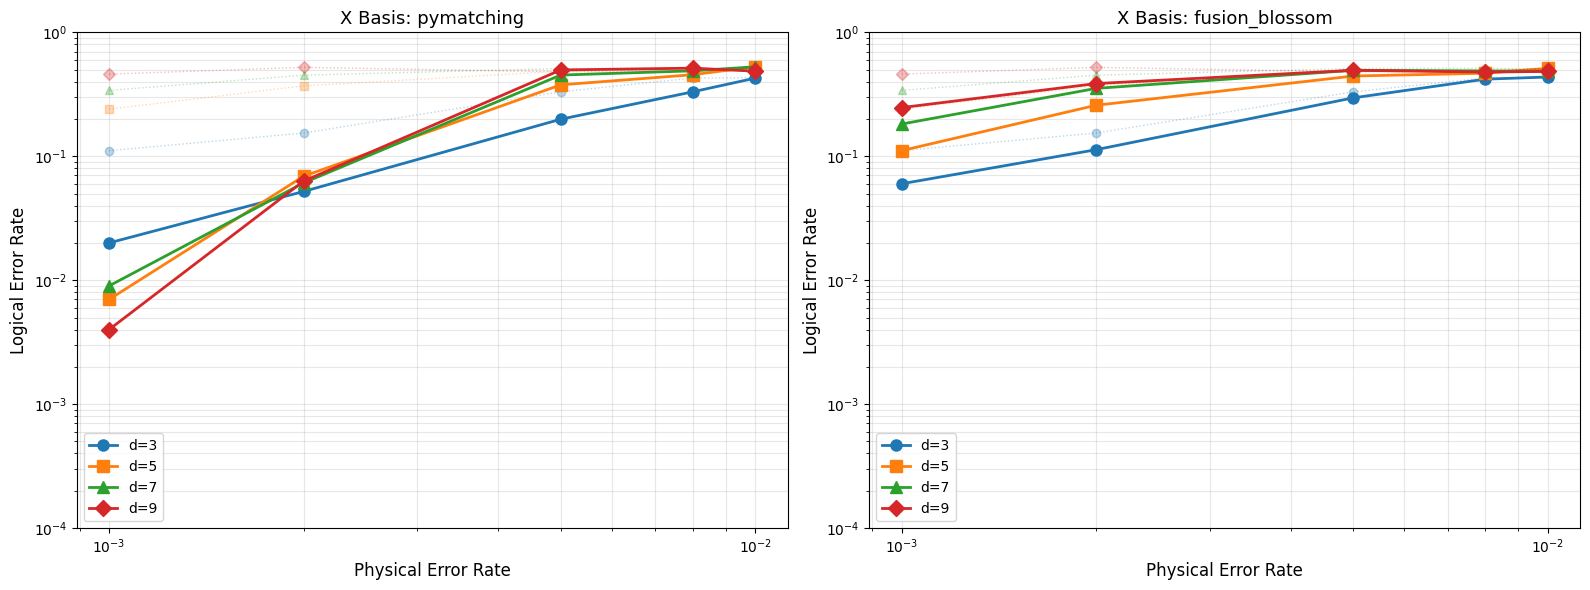

In [9]:
# X basis: compare decoders
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, dt in zip(axes, DECODER_TYPES, strict=False):
    for i, d in enumerate(DISTANCES):
        d_dec = [(p, dec) for (dd, p, dec, raw) in results_x[dt] if dd == d]
        if d_dec:
            ps, lers = zip(*d_dec, strict=False)
            lers_plot = [max(v, 1e-4) for v in lers]
            ax.plot(ps, lers_plot, f"{markers[i]}-", color=colors[i],
                    label=f"d={d}", markersize=8, linewidth=2)

        d_raw = [(p, raw) for (dd, p, dec, raw) in results_x[dt] if dd == d]
        if d_raw:
            ps, lers = zip(*d_raw, strict=False)
            lers_plot = [max(v, 1e-4) for v in lers]
            ax.plot(ps, lers_plot, f"{markers[i]}:", color=colors[i],
                    alpha=0.3, markersize=6, linewidth=1)

    ax.set_xlabel("Physical Error Rate", fontsize=12)
    ax.set_ylabel("Logical Error Rate", fontsize=12)
    ax.set_title(f"X Basis: {dt}", fontsize=13)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_ylim(1e-4, 1.0)

plt.tight_layout()
plt.show()

## Part 5: Logical Error Rate per Syndrome Round

In a memory experiment with $N$ syndrome rounds, the logical state undergoes a random walk
where each round has probability $\epsilon$ of flipping the logical qubit. Since errors can
cancel (two flips = no error), the total logical error probability follows the exponential
decay model:

$$p_L = \frac{1}{2}\left(1 - (1 - 2\epsilon)^N\right)$$

Inverting to extract the per-round logical error rate:

$$\epsilon = \frac{1}{2}\left(1 - (1 - 2 p_L)^{1/N}\right)$$

We can then project to the LER over $d$ rounds (a natural unit for a distance-$d$ code):

$$p_L(d) = \frac{1}{2}\left(1 - (1 - 2\epsilon)^d\right)$$

Reference: [Quantum error correction below the surface code threshold (Google, 2024)](https://arxiv.org/abs/2408.13687)

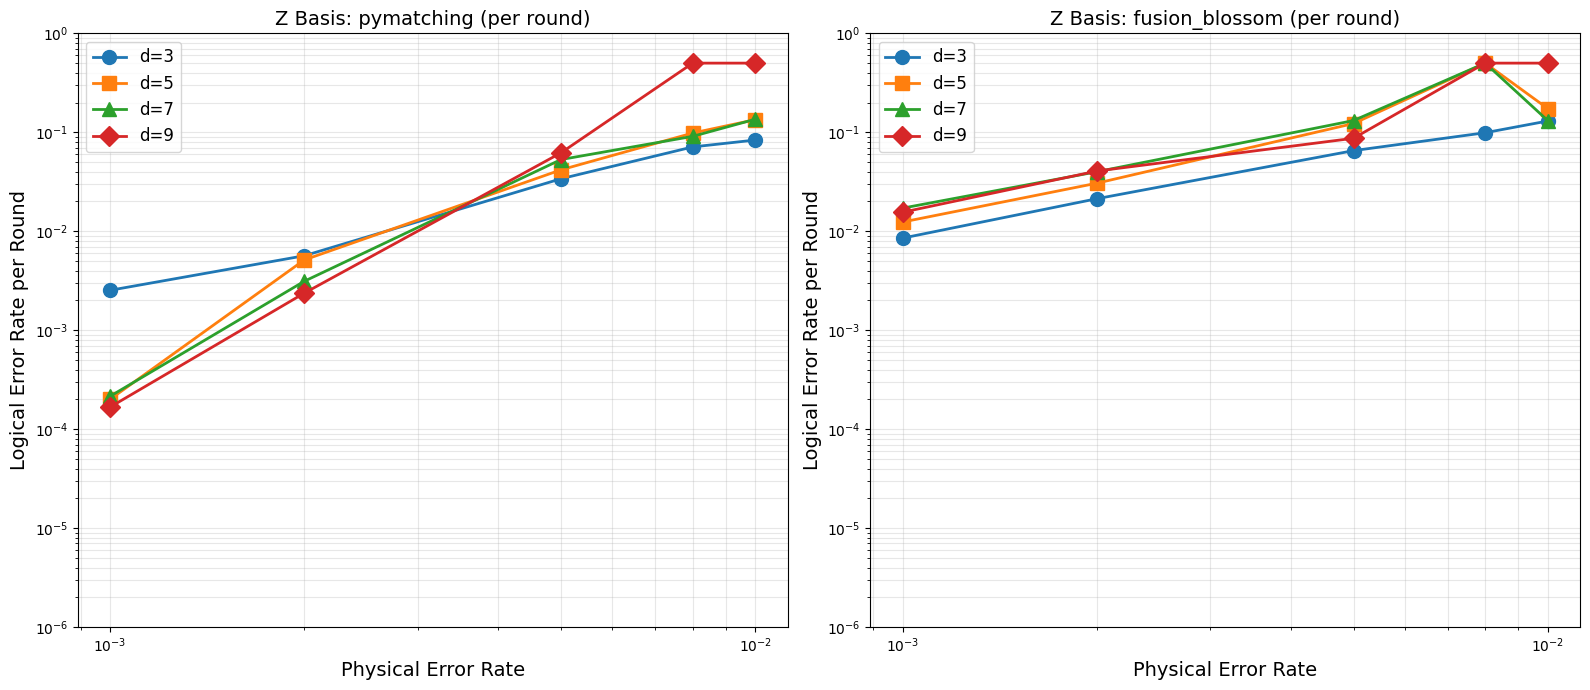

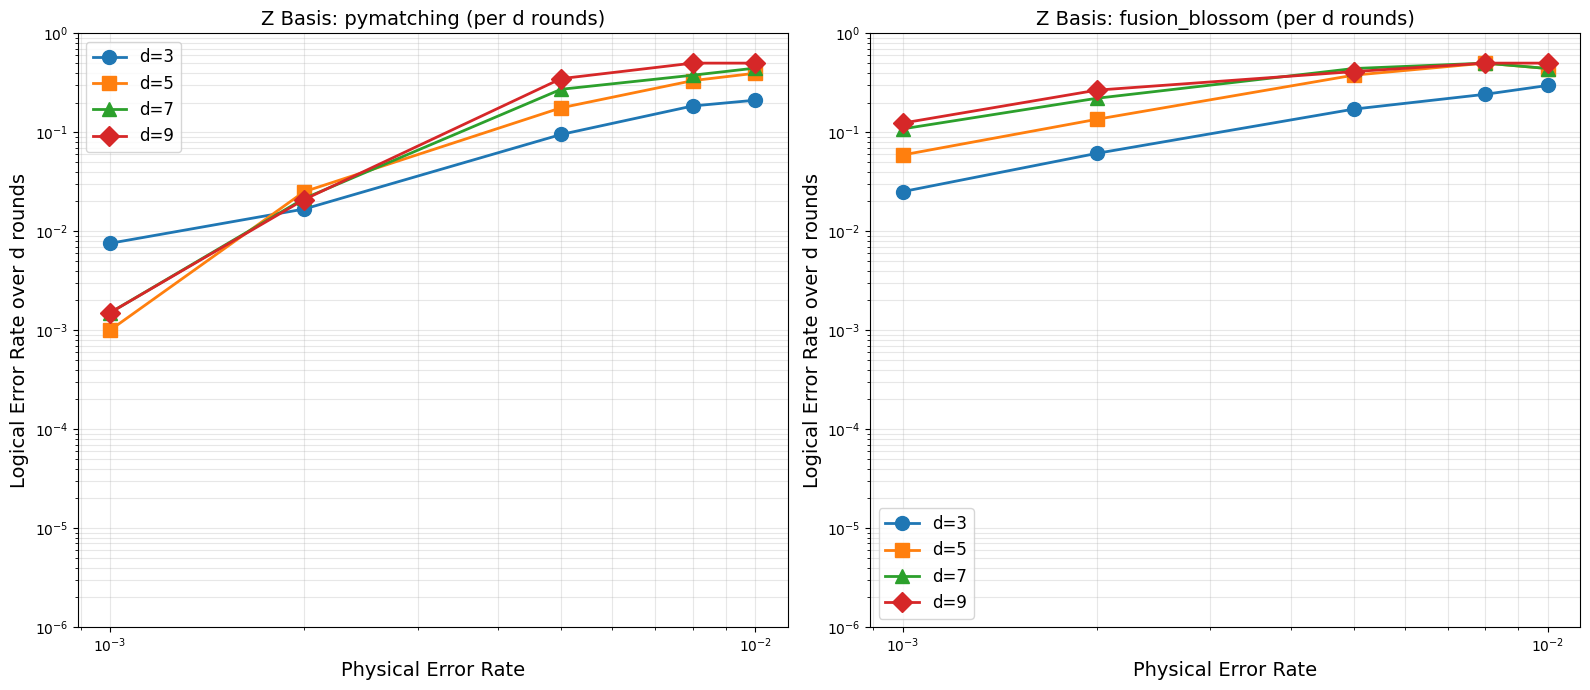


=== Per-Round LER (pymatching, Z basis, exponential decay model) ===
d      rounds  p=0.001     p=0.002     p=0.005     p=0.008     p=0.01      
--------------------------------------------------------------------------
3      6       0.002532    0.005658    0.033927    0.071171    0.083520    
5      10      0.000200    0.005131    0.041766    0.098309    0.134140    
7      14      0.000215    0.003124    0.053049    0.091027    0.135440    
9      18      0.000167    0.002371    0.062072    0.500000    0.500000    

=== LER over d rounds (pymatching, Z basis) ===
d      rounds  p=0.001     p=0.002     p=0.005     p=0.008     p=0.01      
--------------------------------------------------------------------------
3      6       0.007557    0.016782    0.095031    0.184564    0.211036    
5      10      0.001001    0.025132    0.176735    0.332668    0.395119    
7      14      0.001502    0.021461    0.271965    0.377526    0.445228    
9      18      0.001502    0.020938    0.348342

In [10]:
def ler_per_round_exp(ler, num_rounds):
    """Extract per-round logical error rate using exponential decay model.

    Uses: p_L = 1/2 * (1 - (1 - 2*epsilon)^N)
    Inverted: epsilon = 1/2 * (1 - (1 - 2*p_L)^(1/N))
    """
    if ler <= 0:
        return 0.0
    if ler >= 0.5:
        return 0.5
    return 0.5 * (1.0 - (1.0 - 2.0 * ler) ** (1.0 / num_rounds))


def ler_over_d_rounds(epsilon, d):
    """Project per-round error rate to LER over d rounds.

    Uses: p_L(d) = 1/2 * (1 - (1 - 2*epsilon)^d)
    """
    if epsilon <= 0:
        return 0.0
    if epsilon >= 0.5:
        return 0.5
    return 0.5 * (1.0 - (1.0 - 2.0 * epsilon) ** d)


# === Per-round LER (both decoders) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, dt in zip(axes, DECODER_TYPES, strict=False):
    for i, d in enumerate(DISTANCES):
        num_rounds = 2 * d
        d_dec = [(p, dec) for (dd, p, dec, raw) in results_z[dt] if dd == d]
        if d_dec:
            ps, lers = zip(*d_dec, strict=False)
            per_round = [ler_per_round_exp(ler, num_rounds) for ler in lers]
            per_round_plot = [max(v, 1e-6) for v in per_round]
            ax.plot(ps, per_round_plot, f"{markers[i]}-", color=colors[i],
                    label=f"d={d}", markersize=10, linewidth=2)

    ax.set_xlabel("Physical Error Rate", fontsize=14)
    ax.set_ylabel("Logical Error Rate per Round", fontsize=14)
    ax.set_title(f"Z Basis: {dt} (per round)", fontsize=14)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_ylim(1e-6, 1.0)

plt.tight_layout()
plt.show()

# === LER over d rounds (projected from per-round rate) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, dt in zip(axes, DECODER_TYPES, strict=False):
    for i, d in enumerate(DISTANCES):
        num_rounds = 2 * d
        d_dec = [(p, dec) for (dd, p, dec, raw) in results_z[dt] if dd == d]
        if d_dec:
            ps, lers = zip(*d_dec, strict=False)
            per_round = [ler_per_round_exp(ler, num_rounds) for ler in lers]
            ler_d = [ler_over_d_rounds(eps, d) for eps in per_round]
            ler_d_plot = [max(v, 1e-6) for v in ler_d]
            ax.plot(ps, ler_d_plot, f"{markers[i]}-", color=colors[i],
                    label=f"d={d}", markersize=10, linewidth=2)

    ax.set_xlabel("Physical Error Rate", fontsize=14)
    ax.set_ylabel("Logical Error Rate over d rounds", fontsize=14)
    ax.set_title(f"Z Basis: {dt} (per d rounds)", fontsize=14)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_ylim(1e-6, 1.0)

plt.tight_layout()
plt.show()

# === Print tables ===
for dt in DECODER_TYPES:
    print(f"\n=== Per-Round LER ({dt}, Z basis, exponential decay model) ===")
    print(f"{'d':<6} {'rounds':<8}", end="")
    for p in ERROR_RATES:
        print(f"{'p='+str(p):<12}", end="")
    print()
    print("-" * (14 + 12 * len(ERROR_RATES)))
    for d in DISTANCES:
        num_rounds = 2 * d
        print(f"{d:<6} {num_rounds:<8}", end="")
        for p in ERROR_RATES:
            ler = next((dec for (dd, pp, dec, raw) in results_z[dt] if dd == d and pp == p), None)
            if ler is not None:
                pr = ler_per_round_exp(ler, num_rounds)
                print(f"{pr:<12.6f}", end="")
        print()

    print(f"\n=== LER over d rounds ({dt}, Z basis) ===")
    print(f"{'d':<6} {'rounds':<8}", end="")
    for p in ERROR_RATES:
        print(f"{'p='+str(p):<12}", end="")
    print()
    print("-" * (14 + 12 * len(ERROR_RATES)))
    for d in DISTANCES:
        num_rounds = 2 * d
        print(f"{d:<6} {num_rounds:<8}", end="")
        for p in ERROR_RATES:
            ler = next((dec for (dd, pp, dec, raw) in results_z[dt] if dd == d and pp == p), None)
            if ler is not None:
                pr = ler_per_round_exp(ler, num_rounds)
                ld = ler_over_d_rounds(pr, d)
                print(f"{ld:<12.6f}", end="")
        print()

## Part 6: Shot Count Estimation

How many shots are needed to resolve the logical error rate with a given confidence?
Using the Wilson score interval, we need approximately $n \approx z^2 / (\epsilon^2 \cdot p_L)$
shots to measure a logical error rate $p_L$ with relative precision $\epsilon$ at
confidence level $z$ (e.g., $z=1.96$ for 95% CI).

In [11]:
def shots_needed(ler, relative_precision=0.1, confidence_z=1.96):
    """Estimate shots needed to resolve LER to given relative precision."""
    if ler <= 0:
        return float("inf")
    return int(np.ceil(confidence_z**2 * (1 - ler) / (relative_precision**2 * ler)))


print("=== Estimated Shots for 10% Relative Precision (95% CI) ===")
print(f"{'d':<6} {'p':<10} {'LER':<12} {'Shots needed':<15}")
print("-" * 43)

dt = "pymatching"
for d in DISTANCES:
    for p in ERROR_RATES:
        ler = next((dec for (dd, pp, dec, raw) in results_z[dt] if dd == d and pp == p), None)
        if ler is not None and ler > 0:
            n = shots_needed(ler)
            print(f"{d:<6} {p:<10.3f} {ler:<12.4f} {n:<15,}")
    print()

=== Estimated Shots for 10% Relative Precision (95% CI) ===
d      p          LER          Shots needed   
-------------------------------------------
3      0.001      0.0150       25,227         
3      0.002      0.0330       11,258         
3      0.005      0.1720       1,850          
3      0.008      0.3010       893            
3      0.010      0.3330       770            

5      0.001      0.0020       191,696        
5      0.002      0.0490       7,456          
5      0.005      0.2910       936            
5      0.008      0.4440       482            
5      0.010      0.4780       420            

7      0.001      0.0030       127,670        
7      0.002      0.0420       8,763          
7      0.005      0.3960       586            
7      0.008      0.4700       434            
7      0.010      0.4940       394            

9      0.001      0.0030       127,670        
9      0.002      0.0410       8,986          
9      0.005      0.4540       463            


## Summary

This notebook demonstrated surface code memory experiments using:

- **Selene** for noisy simulation with uniform circuit-level depolarizing noise
- **PyMatching** MWPM decoder with PECOS native circuit-level DEM
- **FusionBlossom** MWPM decoder with phenomenological noise model
- 2*d syndrome extraction rounds per distance

**Key observations:**
- **PyMatching (circuit-level DEM)**: Below threshold (~0.3%), increasing distance reduces
  the logical error rate as expected. The circuit-level DEM properly models error propagation
  through CNOT gates and captures hook errors.
- **FusionBlossom (phenomenological)**: Uses a simplified noise model that doesn't capture
  circuit-level error correlations, leading to suboptimal decoding at larger distances.
- The per-round logical error rate (exponential decay model) shows clear error suppression
  below threshold for PyMatching.